## DECISION BOUNDARY — MASTER CODE COLLECTION

### Imports & Helper Function (Reusable)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

sns.set(style="whitegrid")
np.random.seed(42)


### Universal plotting function

In [2]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


### Generate 2D Classification Dataset

In [3]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### Linear Decision Boundary (Logistic Regression)

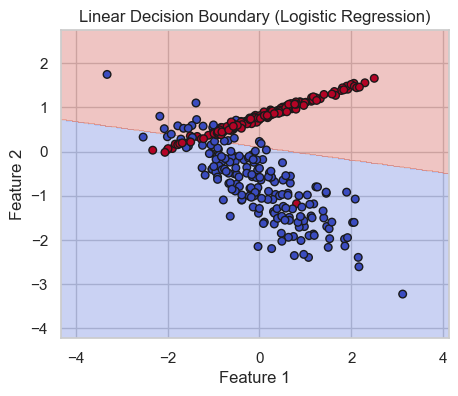

In [4]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

plot_decision_boundary(
    log_reg, X_train, y_train,
    title="Linear Decision Boundary (Logistic Regression)"
)
plt.show()


### Non-Linear Boundary (SVM with RBF Kernel)

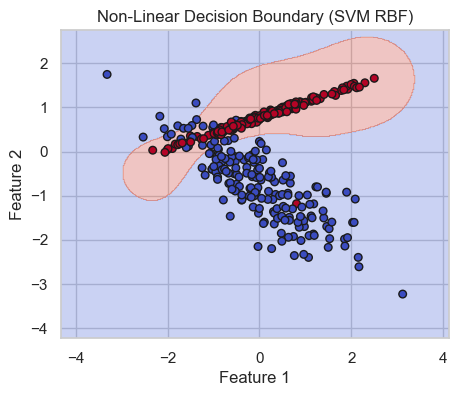

In [5]:
svm_rbf = SVC(kernel="rbf", gamma=1.0)
svm_rbf.fit(X_train, y_train)

plot_decision_boundary(
    svm_rbf, X_train, y_train,
    title="Non-Linear Decision Boundary (SVM RBF)"
)
plt.show()


### Highly Flexible Boundary (k-NN)

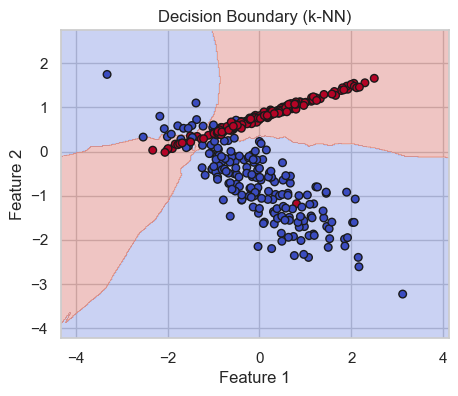

In [6]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

plot_decision_boundary(
    knn, X_train, y_train,
    title="Decision Boundary (k-NN)"
)
plt.show()


### Axis-Aligned Boundary (Decision Tree)

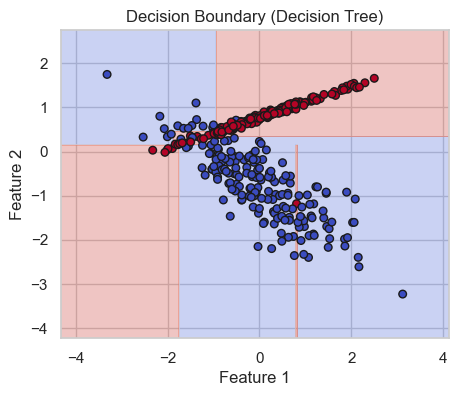

In [7]:
tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)

plot_decision_boundary(
    tree, X_train, y_train,
    title="Decision Boundary (Decision Tree)"
)
plt.show()


### Side-by-Side Comparison (Most Insightful)

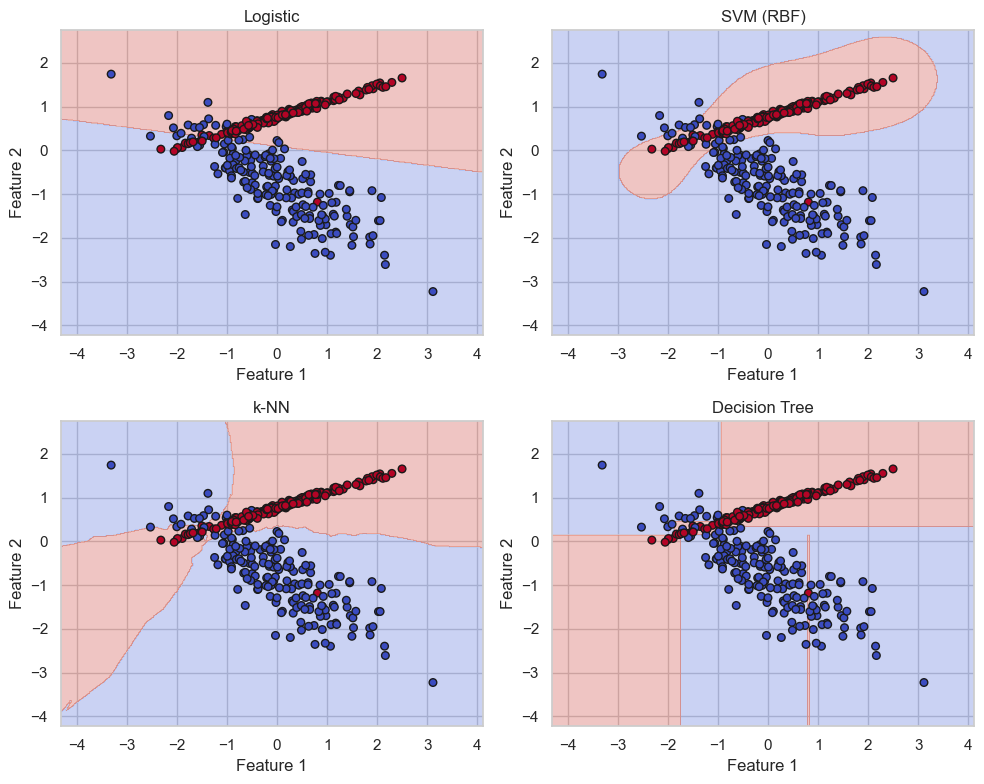

In [8]:
models = {
    "Logistic": LogisticRegression(),
    "SVM (RBF)": SVC(kernel="rbf", gamma=1.0),
    "k-NN": KNeighborsClassifier(7),
    "Decision Tree": DecisionTreeClassifier(max_depth=4)
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X_train, y_train, title=name, ax=ax)

plt.tight_layout()
plt.show()


### Probabilistic Decision Boundary (Soft Output)

In [9]:
def plot_probability_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm")
    plt.colorbar(label="P(Class = 1)")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
    plt.title("Probability Decision Surface")
    plt.show()


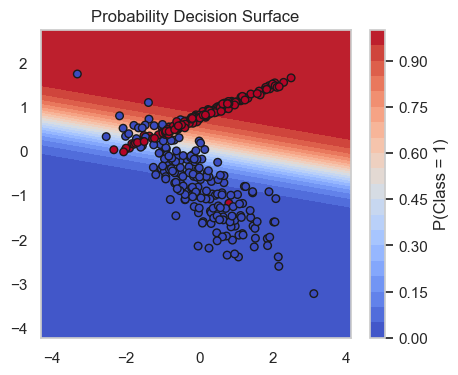

In [10]:
log_reg.fit(X_train, y_train)
plot_probability_boundary(log_reg, X_train, y_train)
